In [1]:
import numpy as np
from itertools import product
from dyn_modelling.models.cell_lattice import build_lattice, simulate_cell_lattice, compute_distance_matrix, compute_rhs
from dyn_modelling.methods.dmd import fit_dmd, fit_edmd, reconstruct, reconstruct_analytic, get_eigenvalues, fit_hodmd, reconstruct_hodmd ,reconstruct_edmd
from dyn_modelling.utils.plots import plot_graph, plot_trajectories, plot_dmd_reconstruction, plot_eigenvalues
from dyn_modelling.utils.data import add_noise
from dyn_modelling.utils.plots import plot_param_heatmap, plot_eigenvalue_grid, plot_reconstruction_grid


## 1. Build the lattice


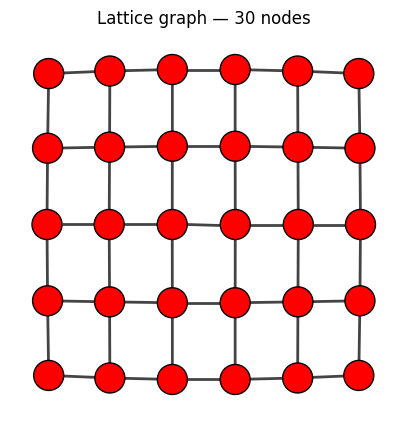

In [2]:
rows, cols = 5, 6
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

## 2. Simulate cell lattice - single trajectory 

In [3]:
# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 10.0, 100.0
t_end = 100.0
neigh_order = 2

#number of time steps for simulation -> total time steps = t_end/delta_t = 400
delta_t = 0.25
t_eval = np.arange(0.0, t_end + delta_t/2, delta_t)
n_steps = len(t_eval)

# Build RHS
dist_matrix = compute_distance_matrix(g)
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)


# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)

# Simulate
y = simulate_cell_lattice(rhs, x0, (0, t_end), t_eval)

In [4]:
np.shape(y)  # (N*3, n_steps)

(90, 401)

## 3. Plot trajectories — clean data


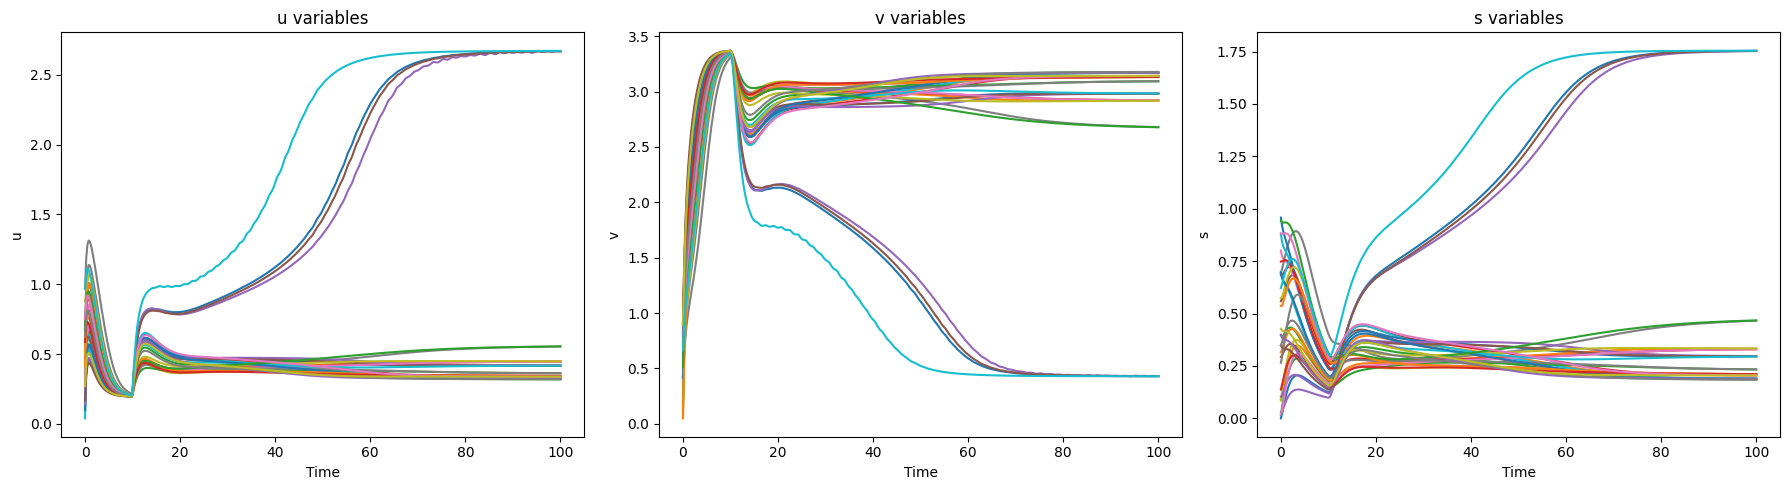

In [5]:
plot_trajectories(t_eval, y)

## 4. Plot trajectories — noisy data


In [6]:
#y_noisy = add_noise(y, noise_level=0.1)
#plot_trajectories(t_eval, y_noisy)

## 5. DMD - clean data

In [7]:
## 4. Fit DMD — clean data
stride = 1   # dt effettivo = 0.25
X_dmd = y[:, ::stride]

dmd_clean = fit_dmd(X_dmd, svd_rank=20)

X_rec_clean = reconstruct(dmd_clean)
X_ana_clean = reconstruct_analytic(dmd_clean, X_dmd)



d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 4744903435.478453. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


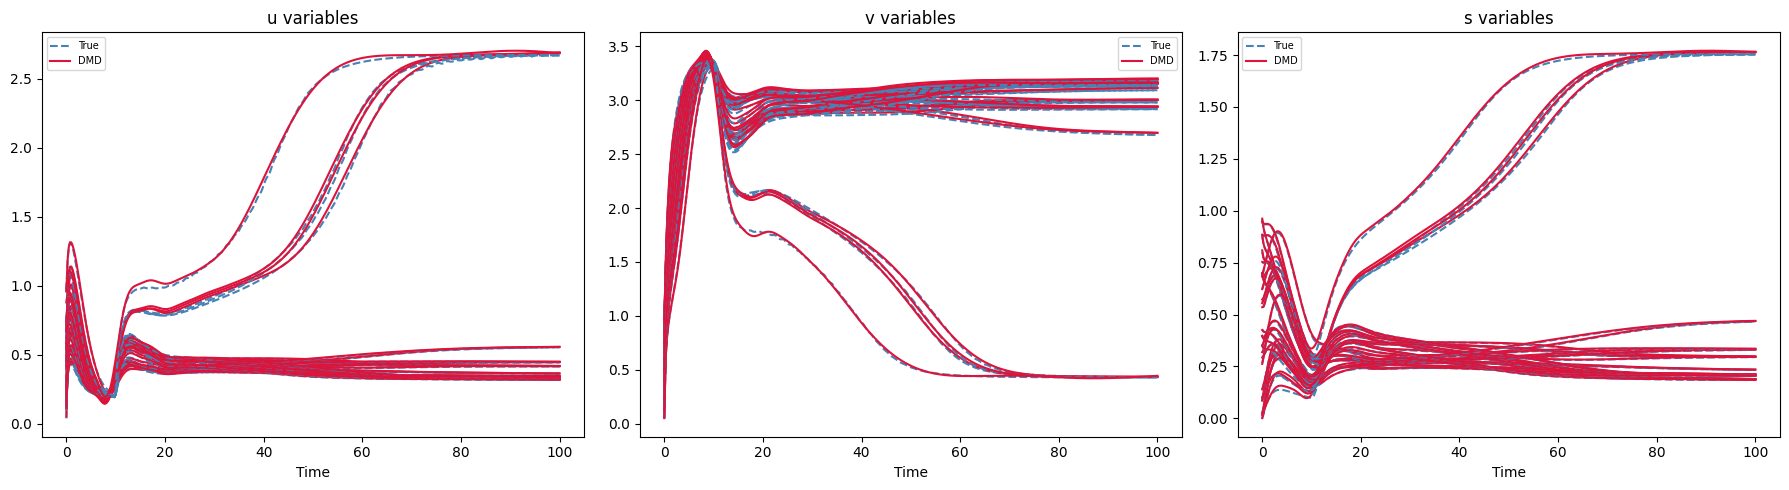

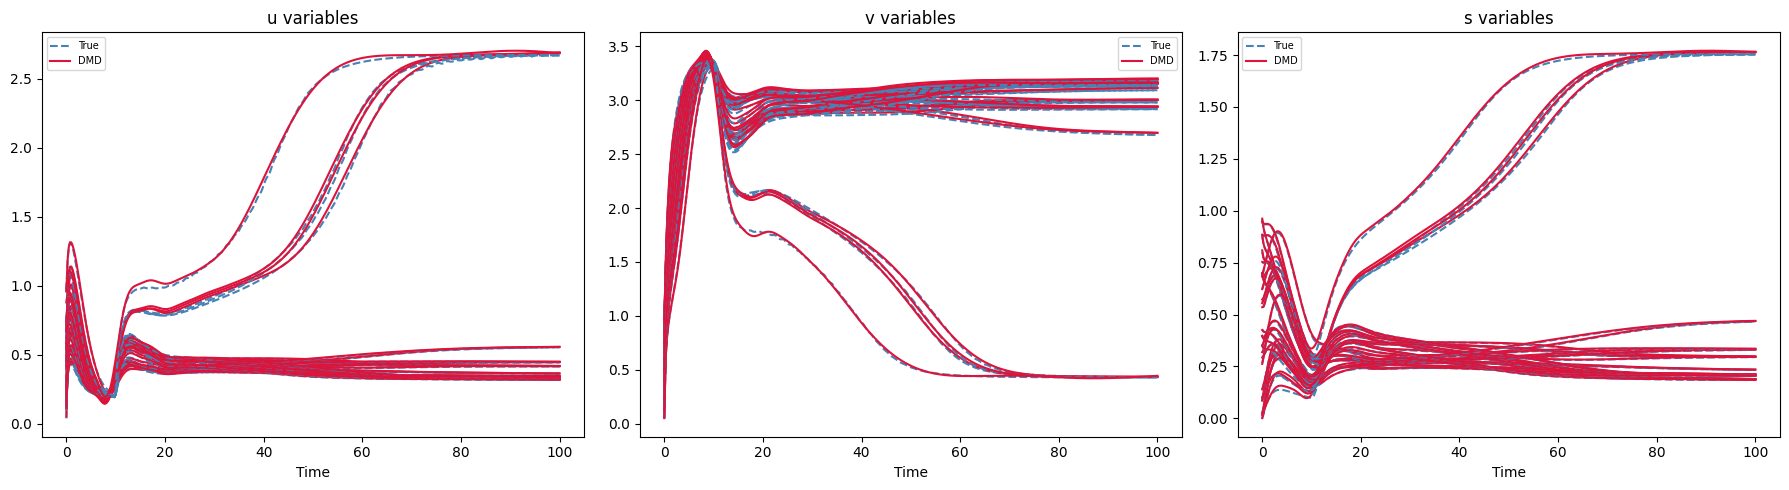

In [8]:
## 5. Plot reconstruction — clean
plot_dmd_reconstruction(t_eval[::stride], y.T[::stride], X_rec_clean, title="DMD reconstruction — clean")
plot_dmd_reconstruction(t_eval[::stride], y.T[::stride], X_ana_clean, title="Analytic DMD reconstruction — clean")

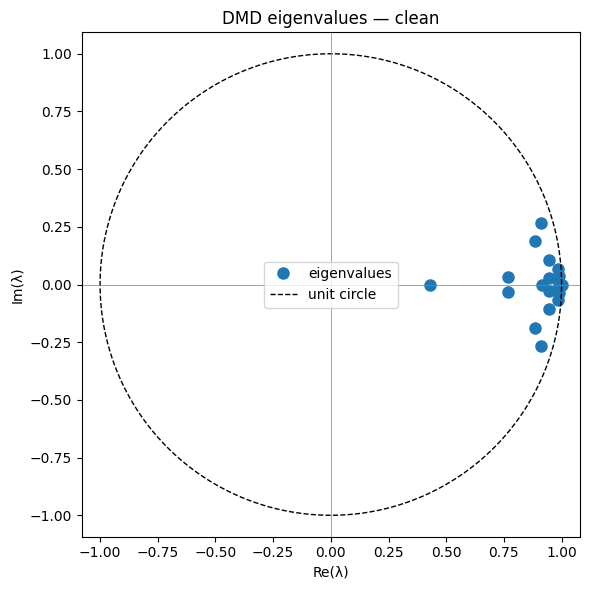

In [9]:
## 6. Plot eigenvalues — clean
plot_eigenvalues(get_eigenvalues(dmd_clean), title="DMD eigenvalues — clean")

In [10]:
strides = [1, 2, 4, 8]
ranks   = [5, 10, 15, 20, 30, 40, 60, 70, 80]
results = {}

for stride, rank in product(strides, ranks):
    X    = y[:, ::stride]
    dmd  = fit_dmd(X, svd_rank=rank)
    eigs = get_eigenvalues(dmd)

    X_rec = reconstruct(dmd)
    n_col = min(X.shape[1], X_rec.shape[0])
    frob_err = np.linalg.norm(X[:, :n_col] - X_rec[:n_col].T) / np.linalg.norm(X[:, :n_col])
    
    results[(stride, rank)] = {
        'dt':          stride * delta_t,
        'eigenvalues': eigs,
        'max_abs_eig': float(np.max(np.abs(eigs))),
        'X':           X,
        'dmd':         dmd,
        'recon_error': float(frob_err),
        'n_steps':     X.shape[1],
    }
    print(f"stride={stride}  dt={results[(stride,rank)]['dt']:.2f}  n_steps={results[(stride,rank)]['n_steps']}  rank={rank}  max|λ|={results[(stride,rank)]['max_abs_eig']:.5f}")

stride=1  dt=0.25  n_steps=401  rank=5  max|λ|=1.00165
stride=1  dt=0.25  n_steps=401  rank=10  max|λ|=0.99985
stride=1  dt=0.25  n_steps=401  rank=15  max|λ|=0.99999
stride=1  dt=0.25  n_steps=401  rank=20  max|λ|=0.99993
stride=1  dt=0.25  n_steps=401  rank=30  max|λ|=1.00002
stride=1  dt=0.25  n_steps=401  rank=40  max|λ|=1.00005
stride=1  dt=0.25  n_steps=401  rank=60  max|λ|=1.00000
stride=1  dt=0.25  n_steps=401  rank=70  max|λ|=1.00000
stride=1  dt=0.25  n_steps=401  rank=80  max|λ|=0.99999
stride=2  dt=0.50  n_steps=201  rank=5  max|λ|=1.00276
stride=2  dt=0.50  n_steps=201  rank=10  max|λ|=0.99982


d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 8040597539.706241. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


stride=2  dt=0.50  n_steps=201  rank=15  max|λ|=0.99997
stride=2  dt=0.50  n_steps=201  rank=20  max|λ|=0.99995
stride=2  dt=0.50  n_steps=201  rank=30  max|λ|=1.00003
stride=2  dt=0.50  n_steps=201  rank=40  max|λ|=1.00008
stride=2  dt=0.50  n_steps=201  rank=60  max|λ|=0.99999
stride=2  dt=0.50  n_steps=201  rank=70  max|λ|=1.00001
stride=2  dt=0.50  n_steps=201  rank=80  max|λ|=1.00000


d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 18396936470.475258. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


stride=4  dt=1.00  n_steps=101  rank=5  max|λ|=1.00435
stride=4  dt=1.00  n_steps=101  rank=10  max|λ|=0.99988
stride=4  dt=1.00  n_steps=101  rank=15  max|λ|=0.99980
stride=4  dt=1.00  n_steps=101  rank=20  max|λ|=0.99992
stride=4  dt=1.00  n_steps=101  rank=30  max|λ|=1.00001
stride=4  dt=1.00  n_steps=101  rank=40  max|λ|=0.99993
stride=4  dt=1.00  n_steps=101  rank=60  max|λ|=1.00000
stride=4  dt=1.00  n_steps=101  rank=70  max|λ|=1.00000
stride=4  dt=1.00  n_steps=101  rank=80  max|λ|=1.00000
stride=8  dt=2.00  n_steps=51  rank=5  max|λ|=1.00764
stride=8  dt=2.00  n_steps=51  rank=10  max|λ|=1.00111
stride=8  dt=2.00  n_steps=51  rank=15  max|λ|=1.00042
stride=8  dt=2.00  n_steps=51  rank=20  max|λ|=0.99998
stride=8  dt=2.00  n_steps=51  rank=30  max|λ|=1.00001
stride=8  dt=2.00  n_steps=51  rank=40  max|λ|=1.00003
stride=8  dt=2.00  n_steps=51  rank=60  max|λ|=1.06275
stride=8  dt=2.00  n_steps=51  rank=70  max|λ|=1.06275
stride=8  dt=2.00  n_steps=51  rank=80  max|λ|=1.06275


d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 466148121.4540793. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


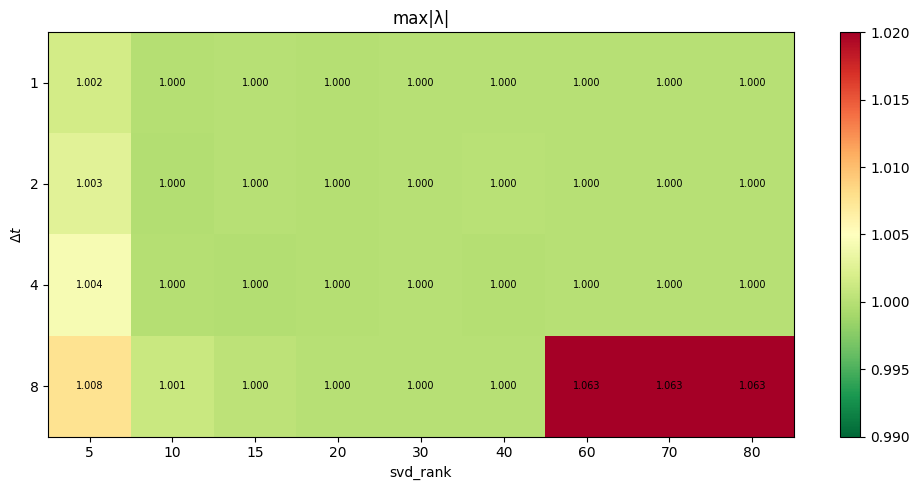

In [11]:
plot_param_heatmap(results, strides, ranks, 'max_abs_eig', row_label="$\\Delta t$", title="max|λ|", vmin=0.99, vmax=1.02)



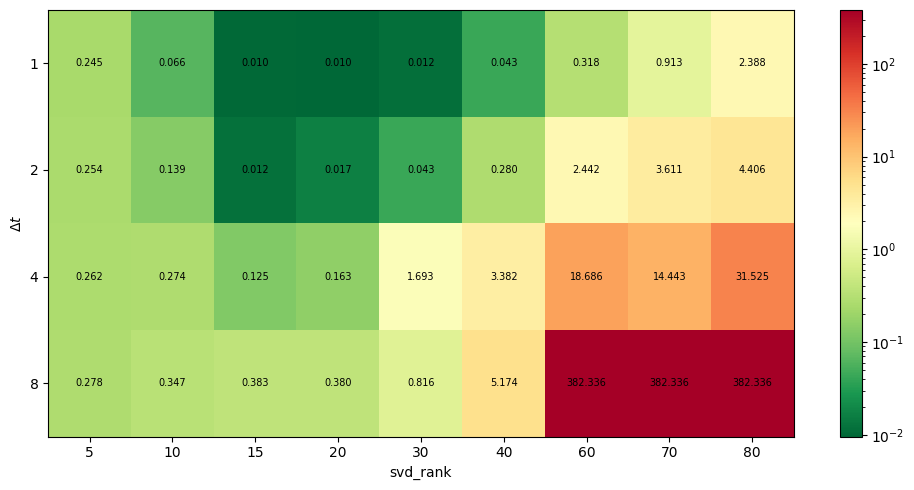

In [12]:
plot_param_heatmap(results, strides, ranks, 'recon_error', row_label="$\\Delta t$", title="", log_scale=True)



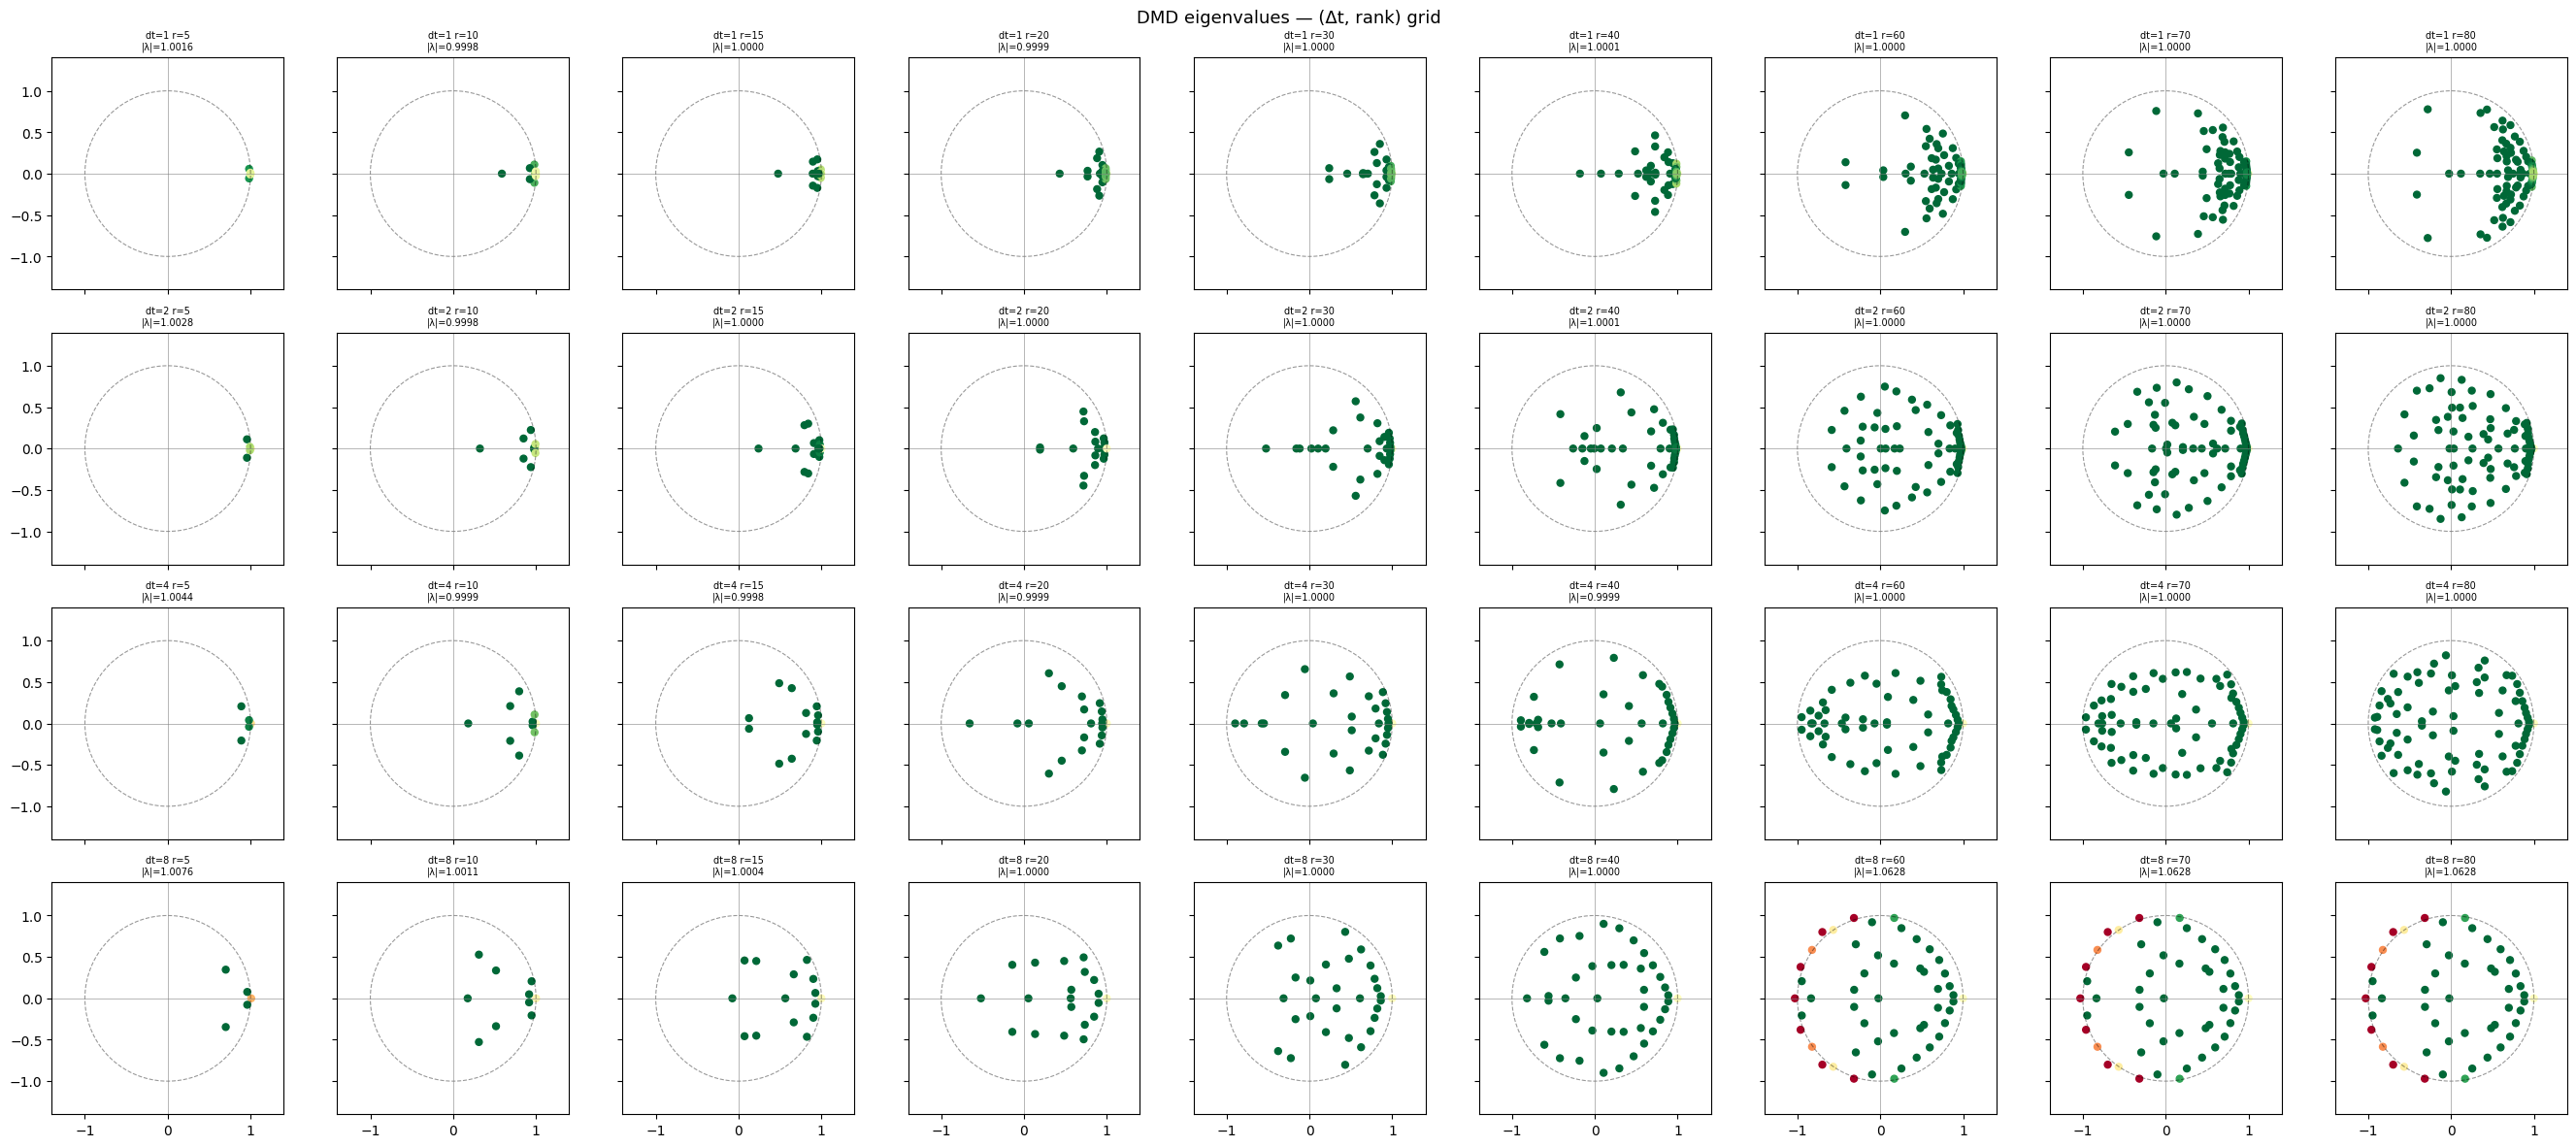

In [13]:
plot_eigenvalue_grid(results, strides, ranks, row_label="dt", title="DMD eigenvalues — (Δt, rank) grid")



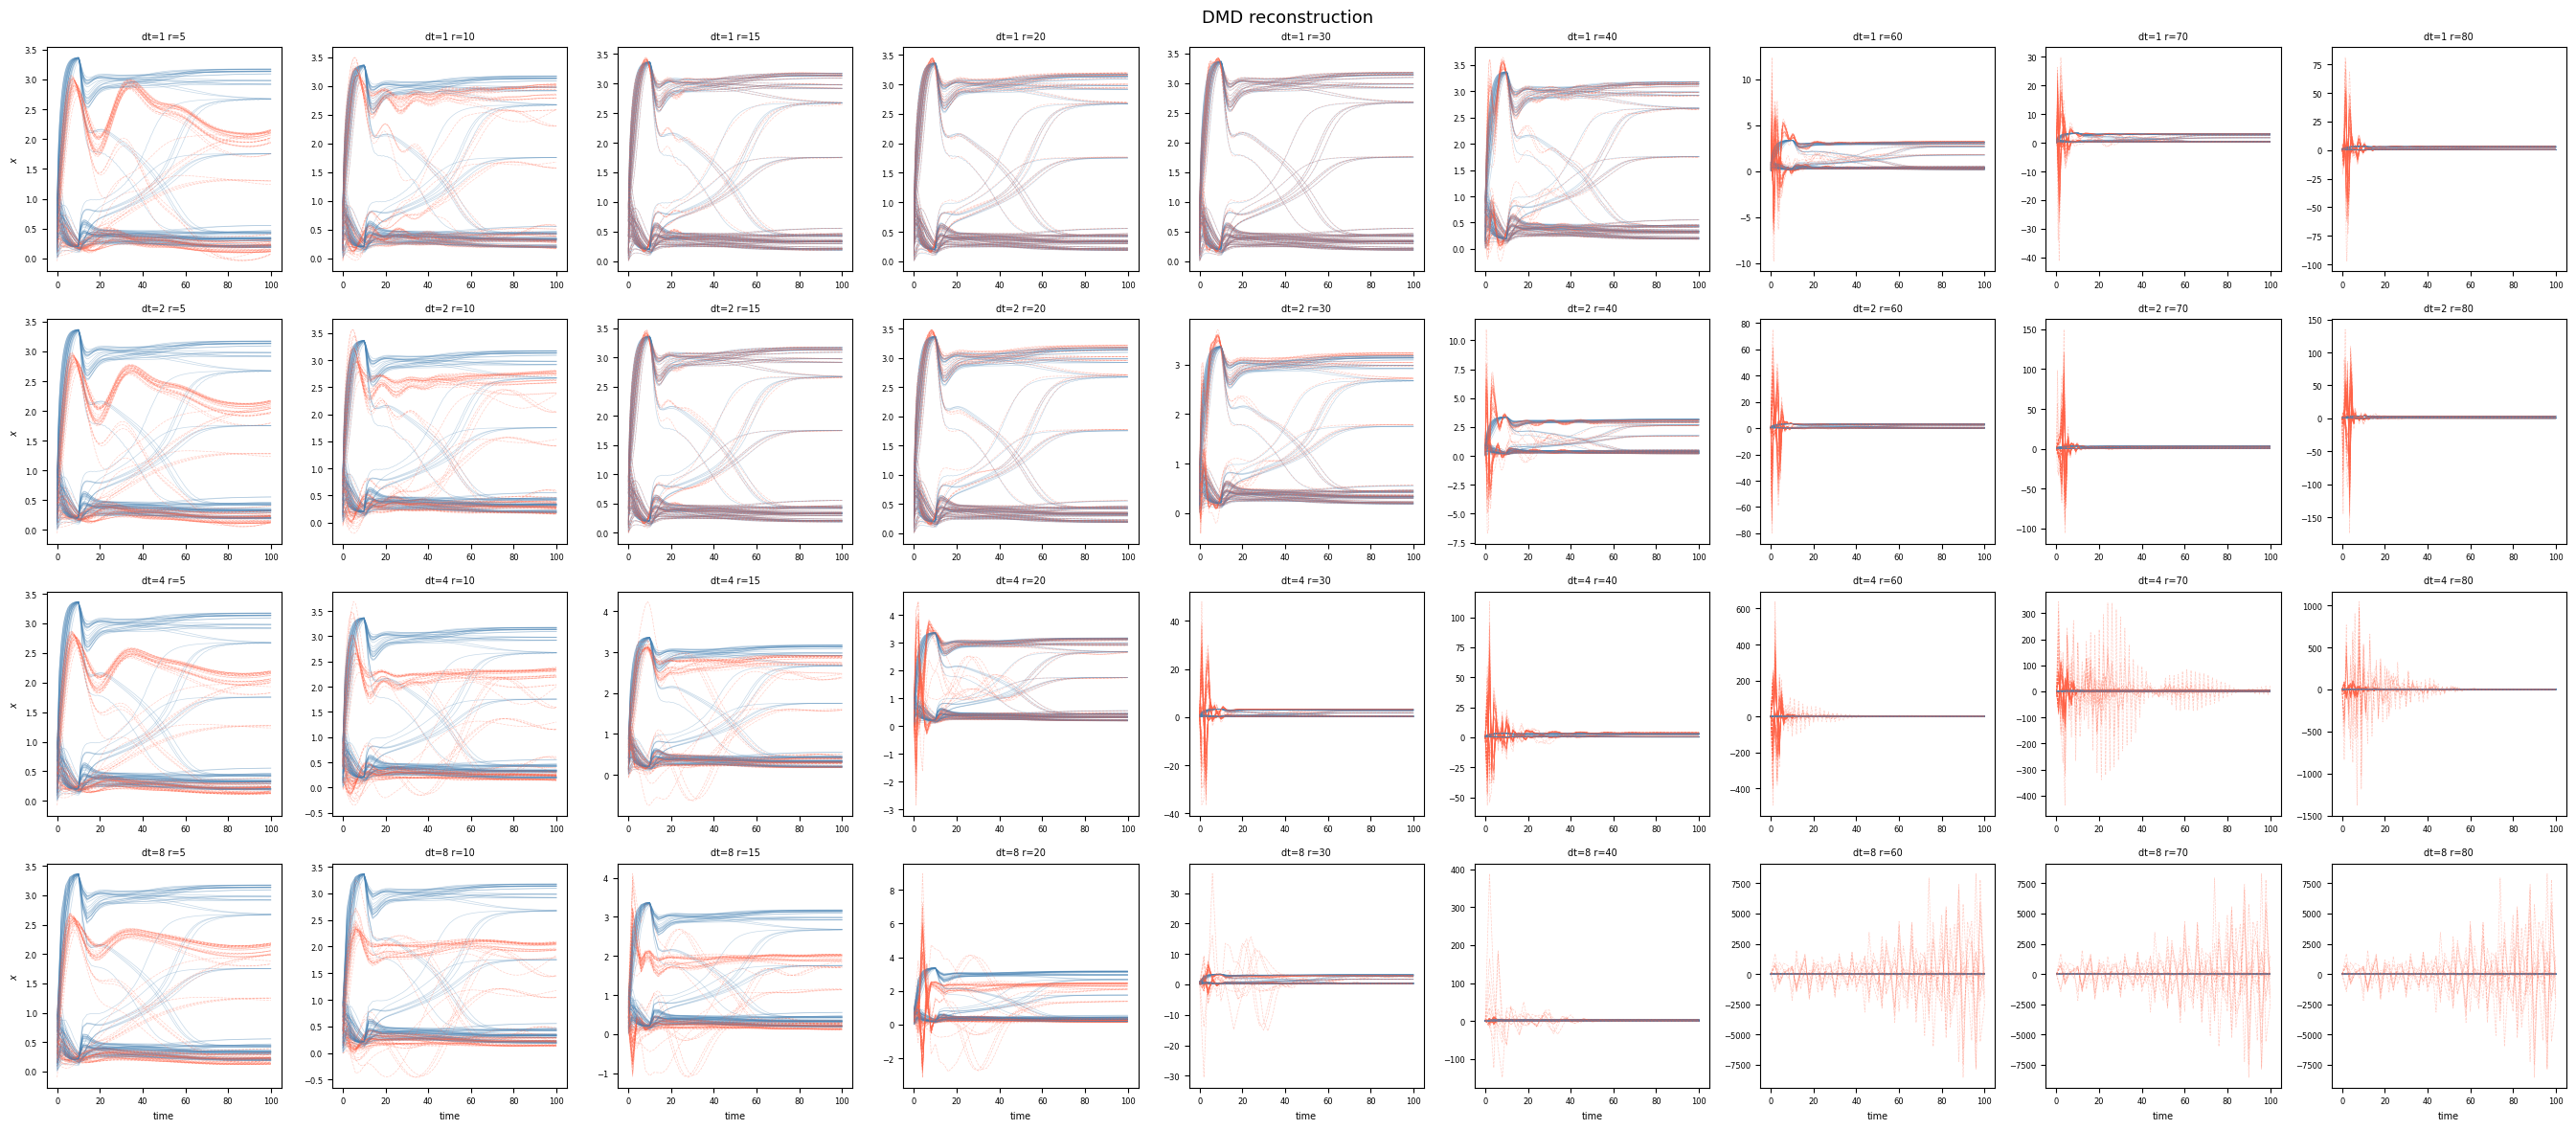

In [25]:
plot_reconstruction_grid(results, strides, ranks, lambda r: reconstruct(r['dmd']),
                          row_label="dt", title="DMD reconstruction", all_states=True)

## 6.EDMD - clean data

In [15]:
# polynomial degree 2 — u², v², s², uv, us, vs per cell , and identity
def obs_polynomial(X, degree=2):
    N = X.shape[0]
    rows = [X]
    if degree >= 2:
        rows.append(X ** 2)
        n_cells = N // 3
        cross = []
        for i in range(n_cells):
            u, v, s = X[3*i], X[3*i+1], X[3*i+2]
            cross += [u*v, u*s, v*s]
        rows.append(np.array(cross))
    return np.vstack(rows)

# choose your observables here
obs_fns = [
    lambda X: obs_polynomial(X, degree=2),
]

d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 370774259475478.25. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


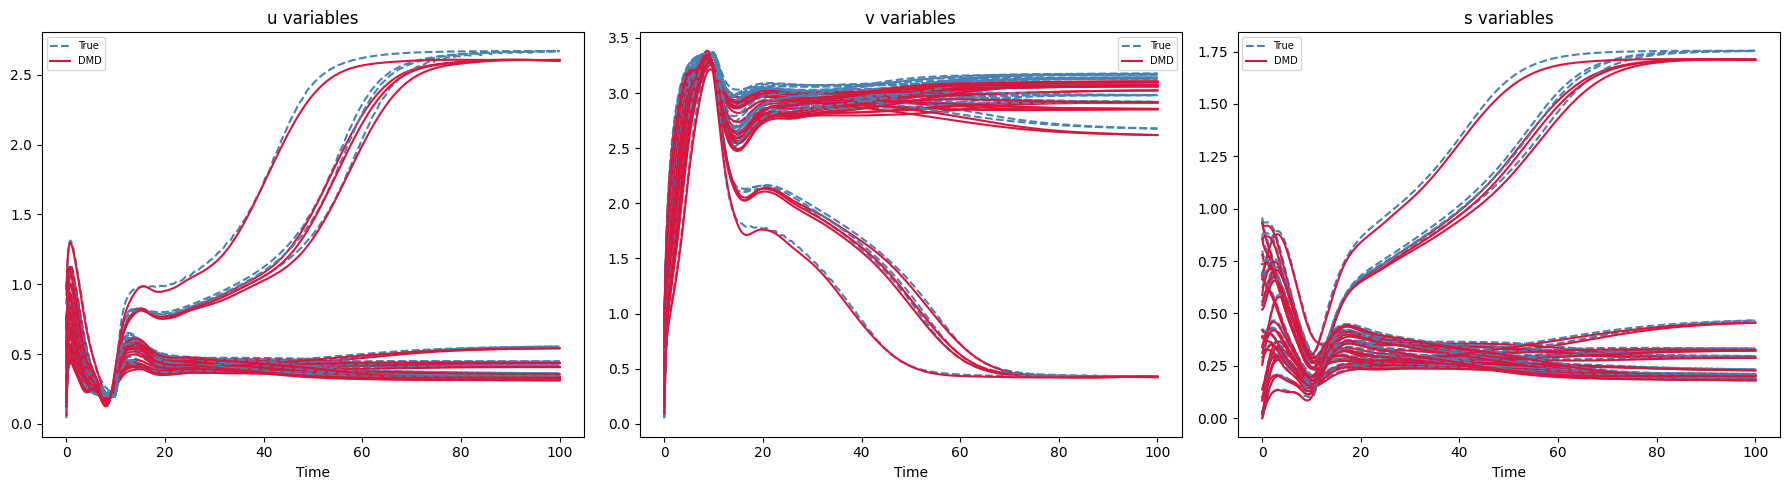

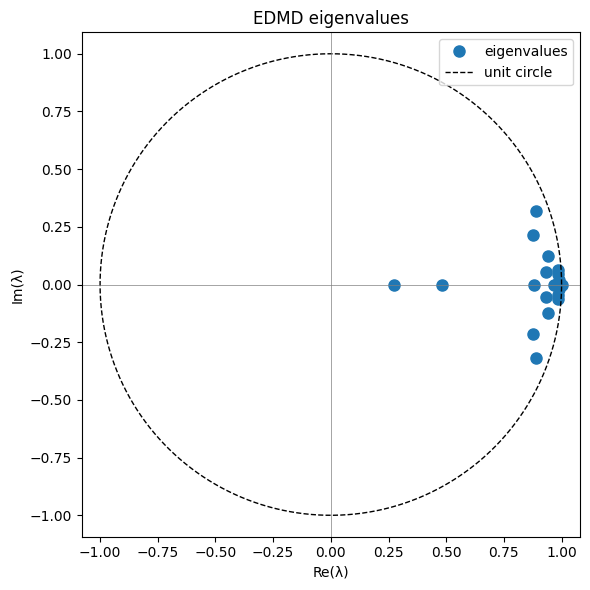

In [16]:
# fit
edmd_clean, n_obs = fit_edmd(y, obs_fns, svd_rank=20)

# reconstruct
X_rec_edmd = reconstruct_edmd(edmd_clean , n_state=3*N)

# plot
plot_dmd_reconstruction(t_eval, y.T, X_rec_edmd, title="EDMD — polynomial degree 2")
plot_eigenvalues(get_eigenvalues(edmd_clean), title="EDMD eigenvalues")

In [17]:
#TEST EDMD

M_values = [270, 400, 500, 600, 800, 1000, 1200]
ranks_edmd = [10, 20, 30, 40, 50, 60, 70, 80, 100, 120, 150, 170, 200, 250]

results_edmd = {}

for M, rank in product(M_values, ranks_edmd):
    X = simulate_cell_lattice(rhs, x0, (0, t_end), np.linspace(0, t_end, M))
        
    edmd, n_obs = fit_edmd(X, obs_fns, svd_rank=rank)
    X_rec = reconstruct_edmd(edmd, n_state=3*N)
    n_col = min(X.shape[1], X_rec.shape[0])
    frob_err = np.linalg.norm(X[:, :n_col] - X_rec[:n_col].T) / np.linalg.norm(X[:, :n_col])
    eigs = get_eigenvalues(edmd)
    
    results_edmd[(M, rank)] = {
        'M':           M,
        'rank':        rank,
        'recon_error': frob_err,
        'edmd':        edmd,
        'X':           X,
        'ratio':       M / 270,  # M/N ratio
        'eigenvalues': eigs,
        'max_abs_eig': float(np.max(np.abs(eigs)))
    }
    print(f"M={M}  rank={rank}  M/N={M/270:.2f}" , f"|λ|={results_edmd[(M, rank)]['max_abs_eig']:.4f}")

d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 2.13326606967827e+17. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


M=270  rank=10  M/N=1.00 |λ|=0.9976
M=270  rank=20  M/N=1.00 |λ|=0.9999
M=270  rank=30  M/N=1.00 |λ|=1.0000
M=270  rank=40  M/N=1.00 |λ|=1.0000
M=270  rank=50  M/N=1.00 |λ|=1.0000
M=270  rank=60  M/N=1.00 |λ|=1.0000
M=270  rank=70  M/N=1.00 |λ|=1.0000
M=270  rank=80  M/N=1.00 |λ|=1.0000
M=270  rank=100  M/N=1.00 |λ|=1.0000
M=270  rank=120  M/N=1.00 |λ|=1.0000
M=270  rank=150  M/N=1.00 |λ|=1.0000
M=270  rank=170  M/N=1.00 |λ|=1.0182
M=270  rank=200  M/N=1.00 |λ|=1.0273
M=270  rank=250  M/N=1.00 |λ|=2.2128


d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 330873610071882.5. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


M=400  rank=10  M/N=1.48 |λ|=0.9988
M=400  rank=20  M/N=1.48 |λ|=0.9999
M=400  rank=30  M/N=1.48 |λ|=1.0000
M=400  rank=40  M/N=1.48 |λ|=1.0000
M=400  rank=50  M/N=1.48 |λ|=1.0000
M=400  rank=60  M/N=1.48 |λ|=1.0000
M=400  rank=70  M/N=1.48 |λ|=1.0000
M=400  rank=80  M/N=1.48 |λ|=1.0000
M=400  rank=100  M/N=1.48 |λ|=1.0000
M=400  rank=120  M/N=1.48 |λ|=1.0000
M=400  rank=150  M/N=1.48 |λ|=1.0000
M=400  rank=170  M/N=1.48 |λ|=1.0000
M=400  rank=200  M/N=1.48 |λ|=1.0012
M=400  rank=250  M/N=1.48 |λ|=1.0347


d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 133189348842518.92. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


...

M=800  rank=10  M/N=2.96 |λ|=0.9997
M=800  rank=20  M/N=2.96 |λ|=1.0000
M=800  rank=30  M/N=2.96 |λ|=1.0000
M=800  rank=40  M/N=2.96 |λ|=1.0000
M=800  rank=50  M/N=2.96 |λ|=1.0000
M=800  rank=60  M/N=2.96 |λ|=1.0000
M=800  rank=70  M/N=2.96 |λ|=1.0000
M=800  rank=80  M/N=2.96 |λ|=1.0000
M=800  rank=100  M/N=2.96 |λ|=1.0000
M=800  rank=120  M/N=2.96 |λ|=1.0000
M=800  rank=150  M/N=2.96 |λ|=1.0000
M=800  rank=170  M/N=2.96 |λ|=1.0000
M=800  rank=200  M/N=2.96 |λ|=1.0000
M=800  rank=250  M/N=2.96 |λ|=1.0061


d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 41704911916373.26. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


M=1000  rank=10  M/N=3.70 |λ|=0.9998
M=1000  rank=20  M/N=3.70 |λ|=1.0000
M=1000  rank=30  M/N=3.70 |λ|=1.0000
M=1000  rank=40  M/N=3.70 |λ|=1.0000
M=1000  rank=50  M/N=3.70 |λ|=1.0000
M=1000  rank=60  M/N=3.70 |λ|=1.0000
M=1000  rank=70  M/N=3.70 |λ|=1.0000
M=1000  rank=80  M/N=3.70 |λ|=1.0000
M=1000  rank=100  M/N=3.70 |λ|=1.0000
M=1000  rank=120  M/N=3.70 |λ|=1.0000
M=1000  rank=150  M/N=3.70 |λ|=1.0000
M=1000  rank=170  M/N=3.70 |λ|=1.0000
M=1000  rank=200  M/N=3.70 |λ|=1.0025
M=1000  rank=250  M/N=3.70 |λ|=1.0051


d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 39123092176310.85. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


M=1200  rank=10  M/N=4.44 |λ|=0.9999
M=1200  rank=20  M/N=4.44 |λ|=1.0000
M=1200  rank=30  M/N=4.44 |λ|=1.0000
M=1200  rank=40  M/N=4.44 |λ|=1.0000
M=1200  rank=50  M/N=4.44 |λ|=1.0000
M=1200  rank=60  M/N=4.44 |λ|=1.0000
M=1200  rank=70  M/N=4.44 |λ|=1.0000
M=1200  rank=80  M/N=4.44 |λ|=1.0000
M=1200  rank=100  M/N=4.44 |λ|=1.0000
M=1200  rank=120  M/N=4.44 |λ|=1.0000
M=1200  rank=150  M/N=4.44 |λ|=1.0000
M=1200  rank=170  M/N=4.44 |λ|=1.0000
M=1200  rank=200  M/N=4.44 |λ|=1.0042
M=1200  rank=250  M/N=4.44 |λ|=1.0041


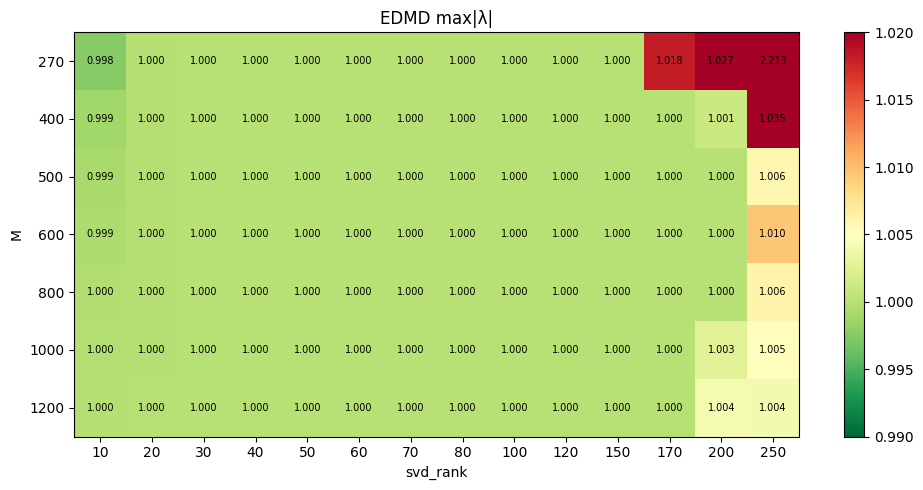

In [18]:
plot_param_heatmap(results_edmd, M_values, ranks_edmd, 'max_abs_eig',
                    row_label="M", col_label="svd_rank",
                    title="EDMD max|λ|",
                    vmin=0.99, vmax=1.02)

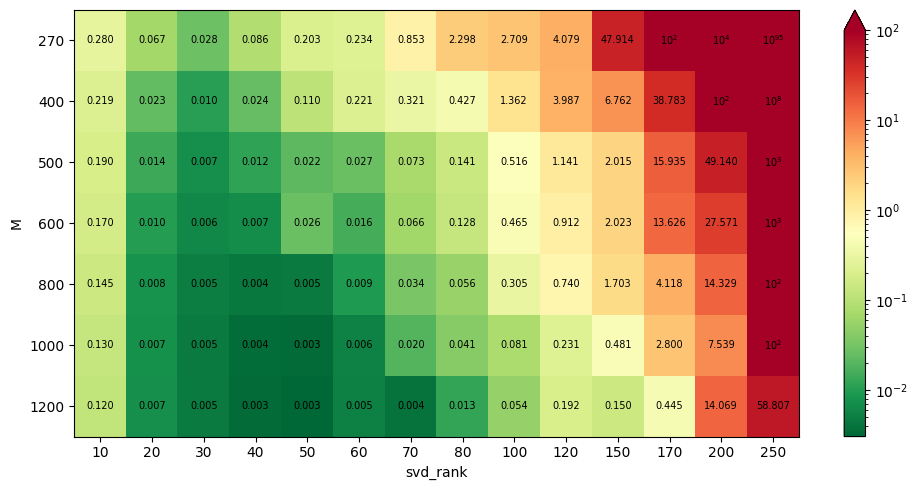

In [19]:
def fmt_val(v):
    if v >= 100:
        return f"$10^{{{int(np.floor(np.log10(v)))}}}$"
    return f"{v:.3f}"

plot_param_heatmap(results_edmd, M_values, ranks_edmd, 'recon_error',
                    row_label="M", title="",
                    log_scale=True, vmax=100, fmt_fn=fmt_val)


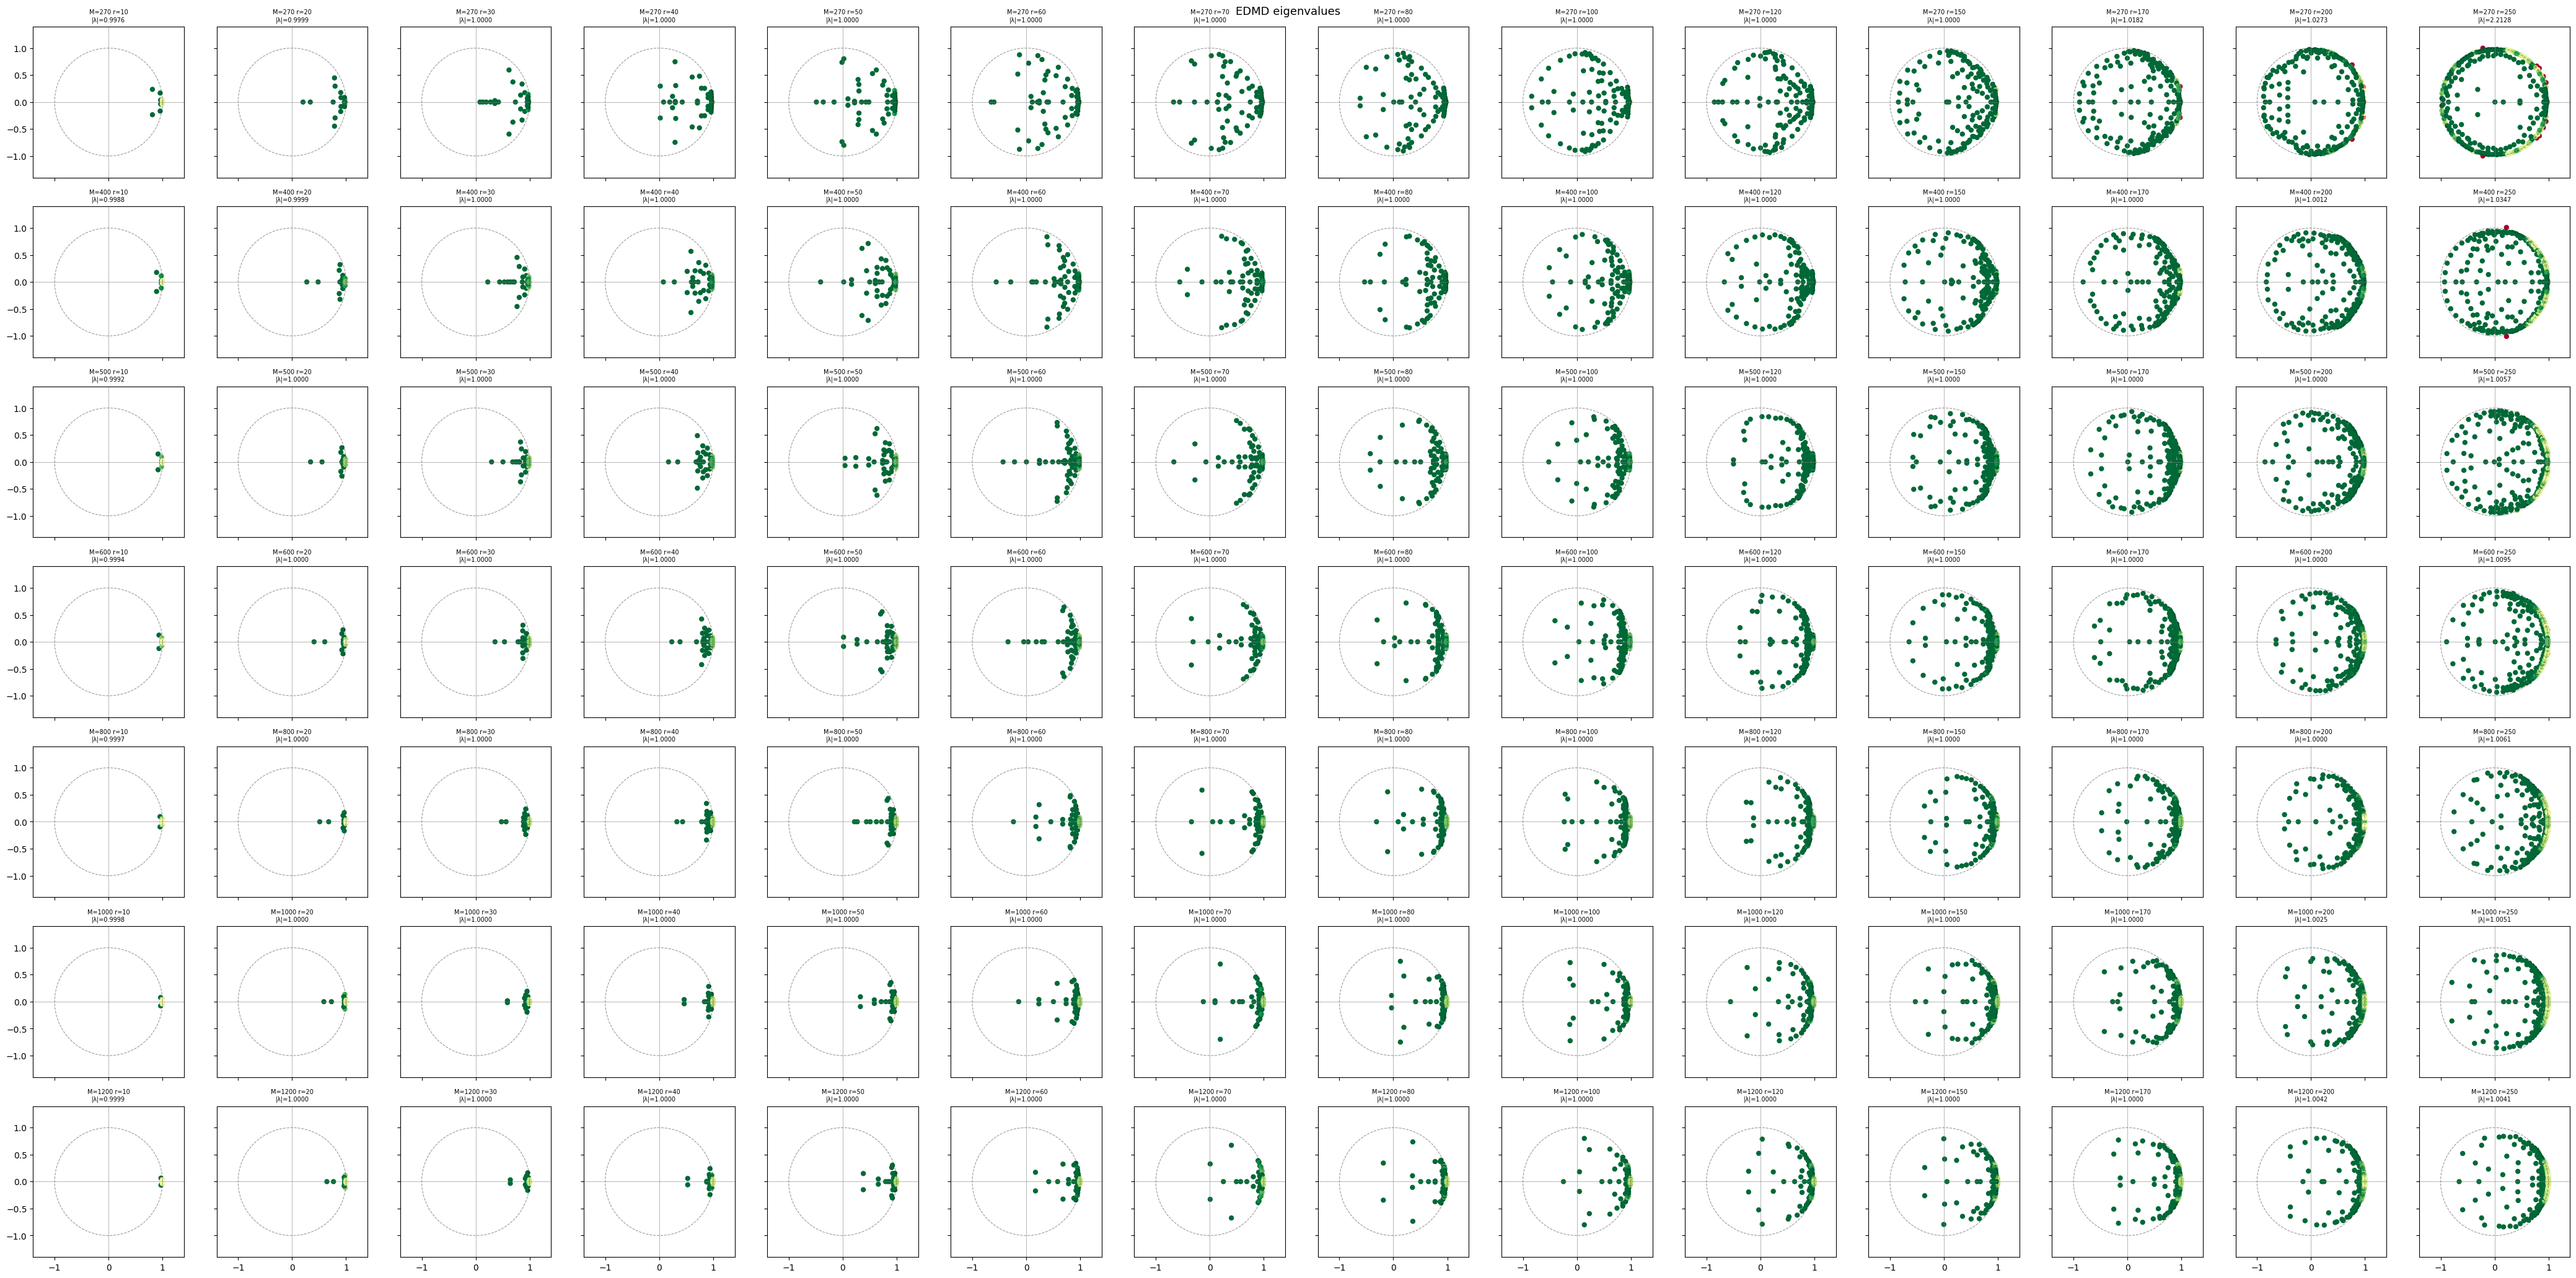

In [20]:

plot_eigenvalue_grid(results_edmd, M_values, ranks_edmd, row_label="M",
                      title="EDMD eigenvalues")

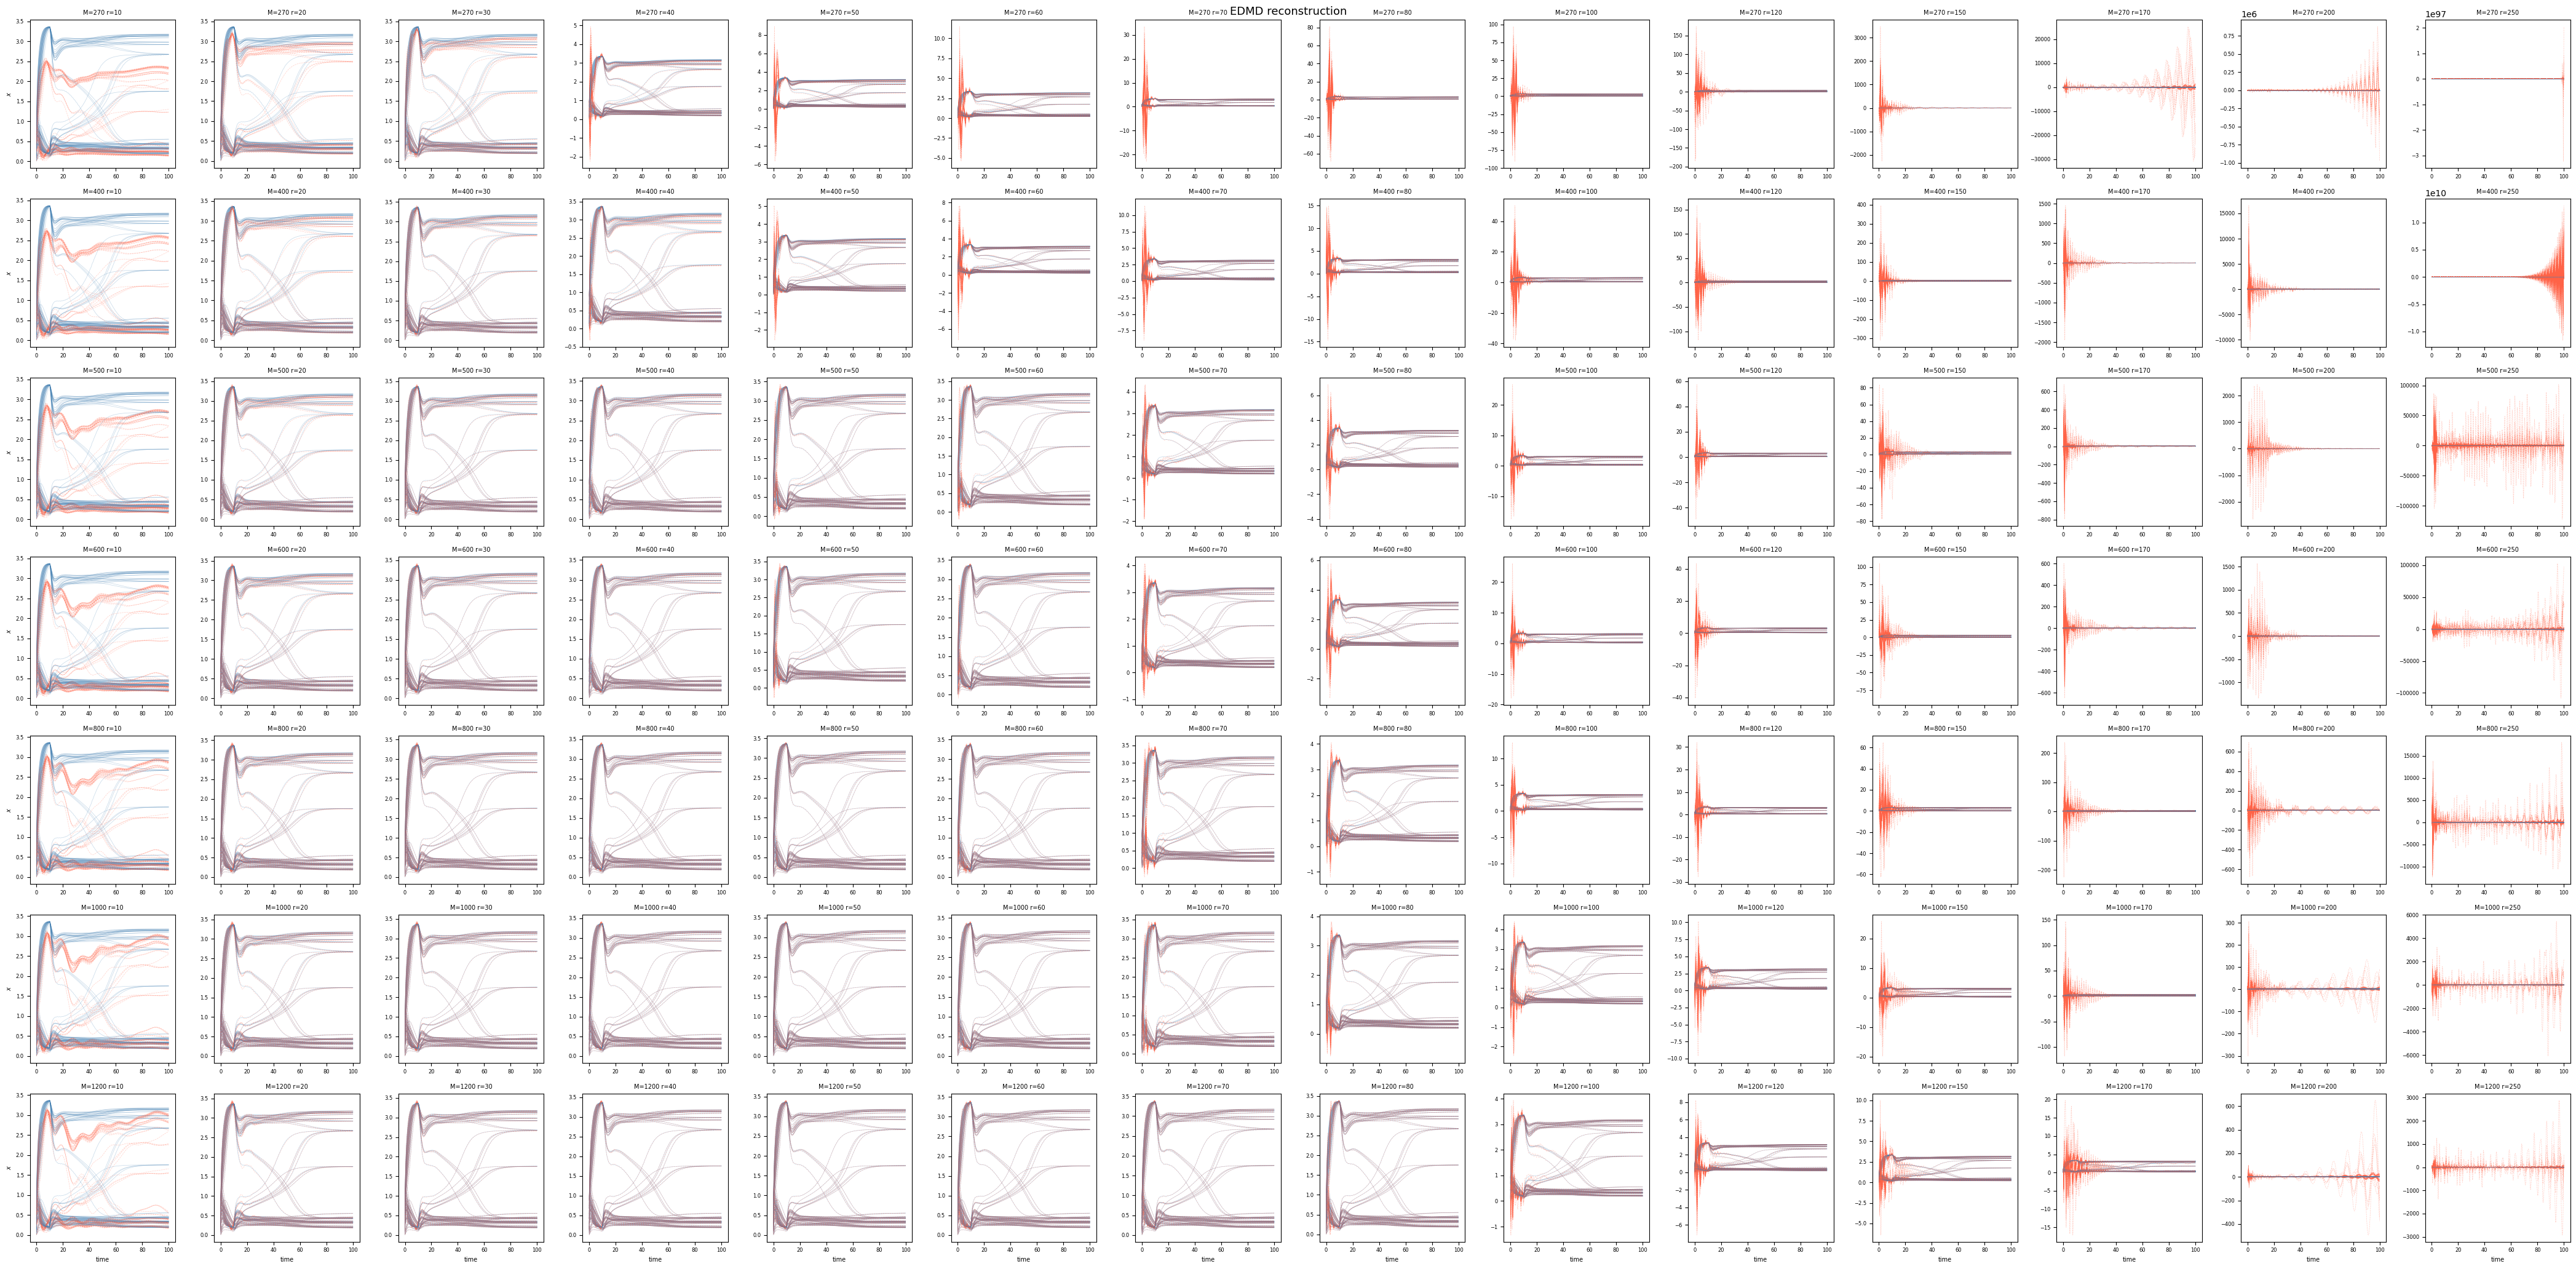

In [21]:
plot_reconstruction_grid(results_edmd, M_values, ranks_edmd,
                          lambda r: reconstruct_edmd(r['edmd'], n_state=3*N),
                          row_label="M", title="EDMD reconstruction", all_states=True,
                          t_fn=lambda r, n: np.linspace(0, t_end, n))

## 7. HODMD - clean data

In [22]:
hodmd = fit_hodmd(y, svd_rank=20, d=20)
X_rec_hodmd = reconstruct_hodmd(hodmd)

d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 4744903435.478453. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 24235144457.846195. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


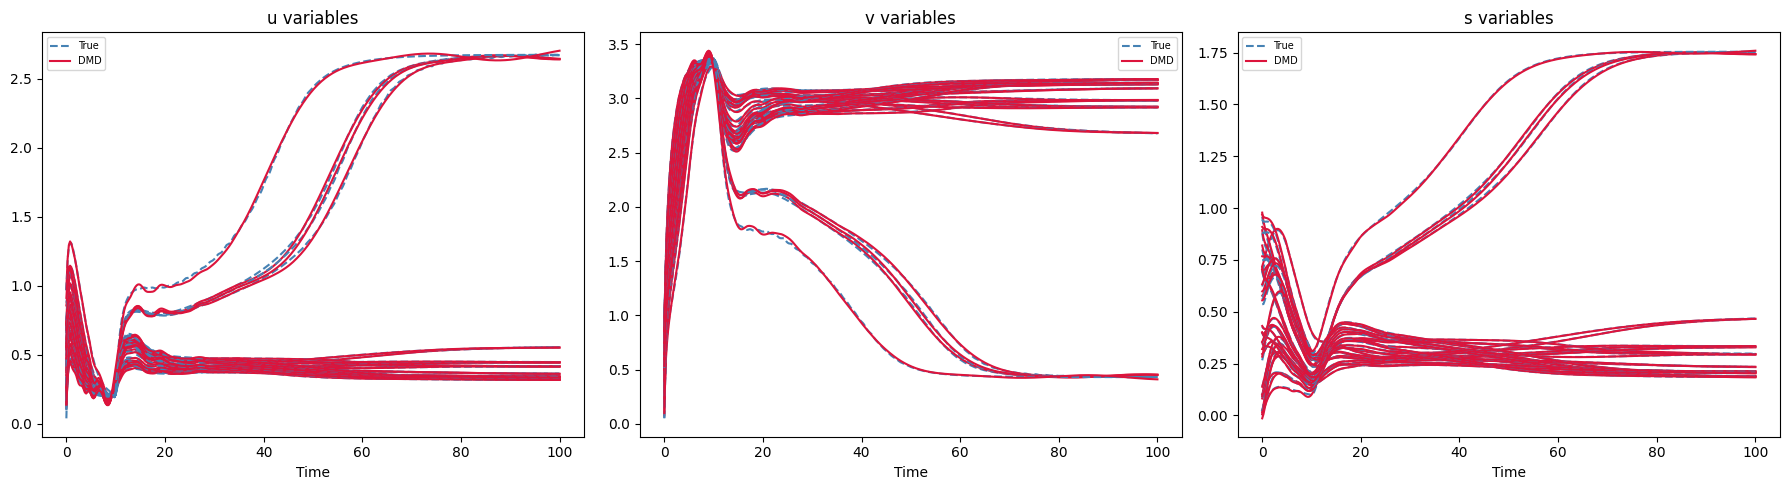

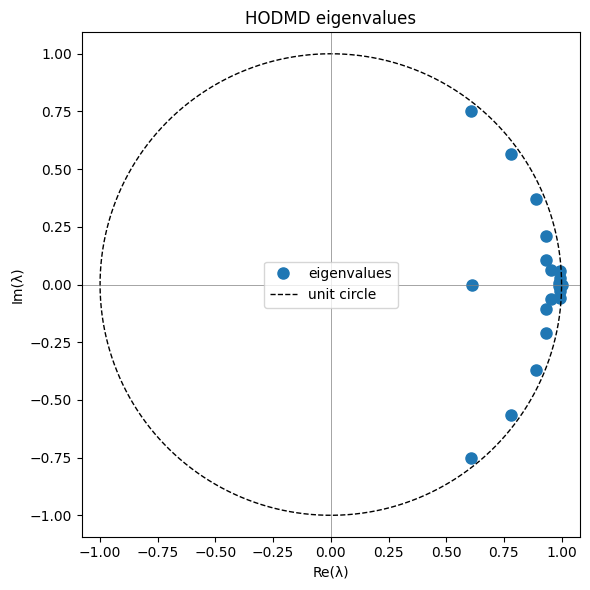

In [23]:
plot_dmd_reconstruction(t_eval, y.T, X_rec_hodmd, title="HODMD reconstruction")
plot_eigenvalues(get_eigenvalues(hodmd), title="HODMD eigenvalues")

## 6. DMD - noisy data

In [24]:
## 7. Fit DMD — noisy data
y_noisy = add_noise(y, noise_level=0.05, seed=42)
plot_trajectories(t_eval, y_noisy)

dmd_noisy = fit_dmd(y_noisy, svd_rank=10)
X_rec_noisy = reconstruct(dmd_noisy)

TypeError: add_noise() got an unexpected keyword argument 'seed'

In [ ]:
## 8. Plot reconstruction — noisy
plot_dmd_reconstruction(t_eval, y_noisy.T, X_rec_noisy, title="DMD reconstruction — noisy")


In [ ]:
## 9. Compare eigenvalues clean vs noisy
plot_eigenvalues(get_eigenvalues(dmd_clean), title="DMD eigenvalues — clean")
plot_eigenvalues(get_eigenvalues(dmd_noisy), title="DMD eigenvalues — noisy")